# NASDAQ-100 Microstructure: Portfolio: Allocator Sweep

**Chapter 17 — Portfolio Construction**

This notebook sweeps **top predictions × TOP_K concentration × allocators** on
the **full universe** to ask a focused question: can portfolio construction
rescue the every-bar strategy that Chapter 16 (Act 1) showed is cost-defeated?
Each combination re-sizes the top baseline-stage predictions with `equal_weight`,
`score_weighted`, or `inverse_vol`, rebalancing every 15-minute bar across all
113 names.

The answer, established below, is that it cannot: every allocator lands deep in
negative territory. Allocator choice and concentration are **second-order** to
the turnover problem — the binding constraint is how often the strategy trades,
not how it weights what it holds. The cost-feasible carrier (Chapter 16,
Section 4) addresses turnover at the *signal* stage through the slot mechanism,
which is itself the position-sizing rule and so does not pass through this
allocator sweep. This notebook therefore documents why standard allocation is
the wrong lever here, motivating the cost-feasibility screen and the cadence
analysis in Chapter 18.

Sections 1–2 generate the full-universe allocation backtests (write to
registry). Section 3 queries the registry via `BacktestExplorer` and can be
re-run independently.

**Learning Objectives:**
1. Sweep top baseline-stage predictions × concentration levels × allocation methods
2. Compare equal-weight, score-weighted, and inverse-vol sizing under intraday costs
3. Show that allocator choice is second-order to trade frequency at 15-minute cadence

**Book Reference:** Chapter 17, Sections 17.2–17.8

**Prerequisites:** Completed Ch16 backtest with results in `registry.db`.

In [1]:
"""NASDAQ-100 Microstructure: Portfolio: Allocator Sweep."""

import time

from case_studies.research import open_study
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    traded_universe_declaration,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.notebook_contracts import excluded_families
from case_studies.utils.registry import read_predictions, resolve_best_predictions
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_expensive_allocators_skip,
    get_top_k_values_for,
    get_top_n_predictions,
    get_universe_filters_for,
)
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
LABEL = ""
MAX_SYMBOLS = 0
# Default value comes from setup.yaml::backtest.sweep.expensive_allocators_skip
# after CASE_STUDY_ID is set; papermill can still override at injection time.
SKIP_EXPENSIVE_ALLOC = None
TOP_N_PREDICTIONS = None
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical branch regenerates in place, which
# needs generated-artifact symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

The study is opened before anything resolves a path or reads the registry. Opening it
activates a root and rewrites `ML4T_OUTPUT_DIR` process-wide, and every later
`get_case_study_dir`, prediction read and registry write resolves against that variable. A
`CASE_DIR` bound before this line points at the released registry while this notebook writes
to the workspace, and the two never meet: the sweep finds nothing registered and every reader
scoped to hashes from the other root comes back empty.

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
if SKIP_EXPENSIVE_ALLOC is None:
    SKIP_EXPENSIVE_ALLOC = get_expensive_allocators_skip(CASE_STUDY_ID)
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")
if excluded_families(CASE_STUDY_ID):
    print(
        "Active-model filter: excluding "
        f"{', '.join(sorted(excluded_families(CASE_STUDY_ID)))} pending corrected reruns"
    )

Case study: nasdaq100_microstructure, label: fwd_ret_15m


## 1. Load Top Predictions from the Baseline Stage

The ranking has to name a universe, because the baseline stage holds two.
`backtest.sweep.signal_passes` scores every admissible prediction on the
cost-feasible universe in pass 1, then re-runs the highest-scoring
`mechanism_top_n` of them on the full universe in pass 2. A ranking that names
neither takes `MAX(sharpe)` over all of a prediction's backtests, so it would
rank most predictions on their cost-feasible number and a handful on whichever
of their two scored higher - a ranking in which no two rows are necessarily the
same measurement.

It names the cost-feasible universe, which is the one `backtest.sweep.
universe_filter` declares canonical and the one `17_costs` and
`20_strategy_analysis` pin to. The alternative is the pass-2 rows, and they are
the narrower question rather than the safer one: pass 2 covers
`mechanism_top_n` predictions, so the ranking would be over eight of them after
a pre-filter that ran on the cost-feasible universe anyway. The cost-feasible
ranking inherits the same pre-filter and ranks the whole population.

**So selection and sweep sit on different universes here, deliberately.** The
predictions are the ones that rank highest where this case study trades; the
allocator sweep then runs them on the full universe, which is the setting the
chapter's question is about. What is avoided is not the crossing - it is
ranking one prediction's full-universe result against another's cost-feasible
one inside a single ordering.

The allocation sweep re-runs these predictions with `equal_weight_top_k`
selection rebalancing every bar, deliberately stripping out the slot
mechanism's turnover control so the allocator comparison is run on the naive
every-bar baseline.

That stripping is what makes this notebook answer a question rather than repeat
one. The slot mechanism allocates a fixed weight per slot and holds it for a
swept `hold_bars`, so in the sweep configuration's own words the slots ARE the
allocation: the mechanism decides what is held, how much of it, and for how
long, in one rule. Feeding it through an allocator sweep would vary the
weighting on top of a turnover control already doing that work, and any
difference between allocators would be read against a baseline that had
already addressed the problem. Running the sweep on the naive every-bar
baseline instead isolates the weighting decision, which is the only decision
an allocator makes.

In [4]:
# The universe the ranking is taken on, read from the same declaration `17_costs`
# and `20_strategy_analysis` pin to rather than typed here, so the three cannot
# drift apart. It is NOT the universe this notebook's own backtests trade:
# `build_backtest_spec` below is handed no `universe_filter`, so every row it
# registers is a full-universe result. The markdown above says why the two differ.
SELECTION_UNIVERSE = get_universe_filters_for(CASE_STUDY_ID)[0]

top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    universe_filter=SELECTION_UNIVERSE,
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
)
if top_preds.is_empty():
    msg = (
        f"No baseline-stage backtests on the {SELECTION_UNIVERSE or 'full'} universe for "
        f"{CASE_STUDY_ID}/{LABEL}/validation, so there is nothing to allocate over. "
        "Every cell below is a no-op on an empty selection, which would register nothing "
        "and report a clean run. `backtest.sweep.signal_passes.baseline_universe` is what "
        "registers these rows; re-run 14_backtest."
    )
    raise RuntimeError(msg)
print(
    f"Top {len(top_preds)} prediction sources by equal-weight baseline Sharpe on the "
    f"{SELECTION_UNIVERSE or 'full'} universe:"
)
print(top_preds.select(["source", "sharpe"]))

Top 10 prediction sources by equal-weight baseline Sharpe on the cost_feasible universe:
shape: (10, 2)
┌────────────────────────────┬───────────┐
│ source                     ┆ sharpe    │
│ ---                        ┆ ---       │
│ str                        ┆ f64       │
╞════════════════════════════╪═══════════╡
│ deep_learning/nlinear      ┆ 2.300125  │
│ gbm/leaves_15_huber        ┆ 1.604085  │
│ gbm/leaves_15_mae          ┆ 1.462935  │
│ gbm/leaves_31_mae          ┆ 1.360184  │
│ gbm/default_mse            ┆ 1.169186  │
│ gbm/leaves_7_mae           ┆ 0.992095  │
│ gbm/leaves_15_mse          ┆ 0.604021  │
│ ensemble/gbm_mean_leaves31 ┆ 0.566403  │
│ deep_learning/lstm_h64     ┆ -5.68276  │
│ gbm/leaves_31_huber        ┆ -5.875727 │
└────────────────────────────┴───────────┘


In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

# `MAX_SYMBOLS` reduces the price panel, and until the run says so in its own specification
# that reduction did not reach `backtest_hash`: a reduced run and the full run over the same
# predictions hashed alike, so the second was served the first's result and the reduction
# bought nothing (ml4t/agent-workspace#911). Declaring it here, before anything is hashed,
# gives a reduced run an identity of its own; `run_backtest` checks the panel against the
# declaration and narrows the predictions to it, so the sweep ranks the cross-section this
# says it ranks and `n_assets` above describes that same set. A full run declares nothing and
# is byte-identical to before.
# A reduced run is a preview run. Refused on the canonical tier so a narrowed result can
# never land in the registry the book's numbers come from, and so the two can never sit in
# one registry to be ranked against each other: `resolve_best_predictions` takes MAX(sharpe)
# over every backtest of a prediction, and a Sharpe earned over a handful of names would
# advance a configuration ahead of one earned over the whole panel. `us_equities_panel` 16
# through 19 already refuse the parameter this way, and `canonically_refused_parameters`
# reads the refusal out of the source, so the canonical fixture path drops the name rather
# than handing the notebook something its first cell raises on.
if EXECUTION_TIER == "canonical" and MAX_SYMBOLS:
    raise ValueError(
        "MAX_SYMBOLS narrows the universe this run trades, which makes it a different "
        "portfolio from the declared one and gives it its own backtest identity "
        "(ml4t/agent-workspace#911). A canonical run trades the declared universe: set "
        "MAX_SYMBOLS=0, or run under EXECUTION_TIER='preview' with a WORKSPACE."
    )
TRADED_UNIVERSE = traded_universe_declaration(prices) if MAX_SYMBOLS else None

Prices: 10,872,848 rows, 113 assets


## 2. Allocation Sweep

For each (prediction × TOP_K × allocator), call `run_backtest()` with the
allocation config added to the strategy spec. The spec hash automatically
differentiates these from baseline-stage backtests.

**The book is long-short, and that shapes every allocator below.**
`get_backtest_config("nasdaq100_microstructure").long_short` is `True`, and the
notebook passes it into both the signal and the allocation spec. So each
decision time selects **two** sets of `TOP_K` names - the top of the ranking
long and the bottom short - and every allocator here normalises the two legs
**separately**: the long weights sum to +1 and the short weights to -1. A
statement below about "the selection" is a statement about one leg.

**The three allocators swept here, and what each one decides.** All three are
handed the same two ranked tails and differ only in the weight they put on each
name:

- **`equal_weight`** is a pass-through: the allocation branch returns the
  weights it was handed, unchanged. The equal sizing it is named for was
  already done one stage earlier, by the `equal_weight_top_k` selection this
  sweep re-runs the predictions under, which gives every name in a leg the same
  share of that leg. So this arm is the null hypothesis in the literal sense -
  it is the book with no allocator applied to it, and the name ranked first and
  the name ranked `TOP_K`-th are held in the same size.
- **`score_weighted`** sizes each name in proportion to the magnitude of its
  predicted score, so the ranking becomes a magnitude rather than an order.
  That is a stronger claim about the model than `equal_weight` makes - it
  asserts the predicted values are calibrated well enough that twice the score
  deserves twice the capital, not merely that the order is right. Weights are
  absolute scores normalised within each leg, with an equal-weight fallback
  applied per leg at any decision time where that leg's scores sum to zero.
- **`inverse_vol`** sizes each name in inverse proportion to its own recent
  realized volatility, so a quiet name carries more capital than a volatile
  one. It uses no property of the prediction at all beyond membership; the
  quantity it reads is a property of the price series. `allocator_lookback` in
  `config/setup.yaml` sets the window that volatility is estimated over, and it
  is counted in rows of the price frame rather than in decision bars: the frame
  is one-minute, and the allocator rolls over its rows without resampling, so
  520 is **520 minutes - about 1.3 sessions**, not the month a
  fifteen-minute reading of it would give. It is the one setting that decides
  how quickly a name's size responds to its own volatility, and at 1.3 sessions
  it responds fast.

The three therefore span a real axis: one uses none of the signal's magnitude,
one uses all of it, and one substitutes a price property for it.

Two further allocators exist and need something the three above do not: a full
covariance or correlation matrix between the held names, rather than a per-name
quantity. `mvo_ledoit_wolf` estimates one under Ledoit-Wolf shrinkage and `hrp`
clusters on a rolling correlation window. Estimated from the same short-horizon
returns being traded, that matrix has far more entries to fill than the return
series has independent observations to fill them from, so it is noisy in a way
a per-name volatility is not, and it is expensive to recompute over the full
history.

`risk_parity` is grouped with them by name and does not belong there:
`compute_risk_parity_weights` weights by inverse volatility raised to 1.5 and
reads no covariance at all, using that exponent as a proxy for the empirical
relation between volatility and correlation. It is a per-name quantity like
`inverse_vol`, and cheap for the same reason. For both reasons this case study does not
declare them at all - `backtest.sweep.allocators` in `config/setup.yaml` names
the three above and nothing else - so `SKIP_EXPENSIVE_ALLOC` below filters a
list they are already absent from. It is there for the case studies that do
declare them, and it is a no-op here.

**`TOP_K` is the other axis, and it decides concentration rather than
weighting.** It is a count per leg, so the book holds at most `2 * TOP_K` names.
A small `TOP_K` bets each leg on the extreme of the ranking, where the model is
most confident and least diversified; a large one walks both legs in towards
the middle of the cross-section, where the ranking barely separates names.

It is swept alongside the allocators because the two interact, though not in a
direction that can be asserted in advance. `score_weighted` differs from
`equal_weight` by however much the selected scores are dispersed **within a
leg**, and that is not a function of how many names the leg holds: five names
on nearly equal scores are weighted nearly equally, and widening to twenty by
admitting lower-scored names spreads them out. Which way `TOP_K` moves the gap
is a question for the results below.

The comparison to draw from this grid is between allocators under one trading
rule, not between allocators and anything else. Every configuration here
rebalances at every decision time across the whole universe, so they all carry
the same turnover, and a weighting scheme redistributes capital across
positions without changing how often those positions turn over.

In [6]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
print(f"TOP_K grid: {TOP_K_VALUES} (universe: {n_assets} assets)")

_ALL_ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)

_EXPENSIVE = {"mvo_ledoit_wolf", "hrp"}
if SKIP_EXPENSIVE_ALLOC:
    ALLOC_CONFIGS = [a for a in _ALL_ALLOC_CONFIGS if a["method"] not in _EXPENSIVE]
    print(
        f"Skipping expensive allocators ({', '.join(_EXPENSIVE)}): covariance "
        f"estimation over {len(prices):,} price rows ({n_assets} symbols) is prohibitive"
    )
else:
    ALLOC_CONFIGS = _ALL_ALLOC_CONFIGS

n_total = len(top_preds) * len(TOP_K_VALUES) * len(ALLOC_CONFIGS)
print(
    f"Total backtests: {len(top_preds)} preds × {len(TOP_K_VALUES)} top_k × "
    f"{len(ALLOC_CONFIGS)} allocs = {n_total}"
)

TOP_K grid: [5, 10, 20] (universe: 113 assets)
Skipping expensive allocators (mvo_ledoit_wolf, hrp): covariance estimation over 10,872,848 price rows (113 symbols) is prohibitive
Total backtests: 10 preds × 3 top_k × 3 allocs = 90


### Run allocation backtest for a single configuration

Helper that builds a backtest spec and runs it. Returns (sharpe, elapsed)
on success, or None on failure. Tracks MVO budget to drop slow allocators.

In [7]:
def run_alloc_backtest(pred_hash, source, top_k, alloc, predictions, state):
    """Run one allocation backtest and update sweep state counters."""
    alloc_name = alloc["method"]
    if state["skip_mvo"] and alloc_name in ("mvo", "mvo_ledoit_wolf"):
        return

    state["n_done"] += 1
    n_done = state["n_done"]

    spec = build_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        prices=prices,
        traded_universe=TRADED_UNIVERSE,
        prediction_hash=pred_hash,
        initial_cash=bt_config.initial_cash,
        chapter="ch17",
        label=LABEL,
        signal={"method": "equal_weight_top_k", "top_k": top_k, "long_short": bt_config.long_short},
        allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
    )

    is_mvo = alloc_name in ("mvo", "mvo_ledoit_wolf")
    t0 = time.monotonic()
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            pred_hash,
            spec,
            prices=prices,
            predictions=predictions,
            label=LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
        )
        elapsed = time.monotonic() - t0

        if is_mvo and not state["skip_mvo"]:
            projected = (time.monotonic() - state["sweep_start"]) + elapsed * (
                len(top_preds) * len(TOP_K_VALUES) - 1
            )
            if projected > BUDGET_SECONDS:
                print(f"    >> Dropping MVO — projected {projected / 60:.0f}m exceeds budget")
                state["skip_mvo"] = True

        sharpe = result.metrics.get("sharpe", 0)
        print(f"  [{n_done}/{n_total}] k={top_k} {source} × {alloc_name}: Sharpe={sharpe:.3f}")
    except Exception as e:
        state["n_failed"] += 1
        print(f"  [{n_done}/{n_total}] k={top_k} {source} × {alloc_name}: FAILED — {e}")

In [8]:
BUDGET_SECONDS = 3600
state = {"n_done": 0, "n_failed": 0, "skip_mvo": False, "sweep_start": time.monotonic()}

for top_k in TOP_K_VALUES:
    print(f"\n--- TOP_K = {top_k} ---")
    for pred_row in top_preds.iter_rows(named=True):
        pred_hash = pred_row["prediction_hash"]
        source = pred_row["source"]
        predictions = read_predictions(CASE_STUDY_ID, pred_hash)
        for alloc in ALLOC_CONFIGS:
            run_alloc_backtest(pred_hash, source, top_k, alloc, predictions, state)

elapsed_min = (time.monotonic() - state["sweep_start"]) / 60
print(
    f"\nSweep completed in {elapsed_min:.1f} minutes ({state['n_done']} done, {state['n_failed']} failed)"
)


--- TOP_K = 5 ---


  [1/90] k=5 deep_learning/nlinear × equal_weight: Sharpe=-4.198


  [2/90] k=5 deep_learning/nlinear × score_weighted: Sharpe=-4.839


  [3/90] k=5 deep_learning/nlinear × inverse_vol: Sharpe=-6.439


  [4/90] k=5 gbm/leaves_15_huber × equal_weight: Sharpe=-4.956


...

  [86/90] k=20 deep_learning/lstm_h64 × score_weighted: Sharpe=-17.644


  [87/90] k=20 deep_learning/lstm_h64 × inverse_vol: Sharpe=-28.315


  [88/90] k=20 gbm/leaves_31_huber × equal_weight: Sharpe=-11.205


  [89/90] k=20 gbm/leaves_31_huber × score_weighted: Sharpe=-6.189


  [90/90] k=20 gbm/leaves_31_huber × inverse_vol: Sharpe=-13.623

Sweep completed in 92.9 minutes (90 done, 0 failed)


## 3. Allocation Analysis

This section is **read-only** — it queries the registry via `BacktestExplorer`
and can be re-run independently without re-running the sweep.

Key question: does allocator choice change the outcome on the full universe,
or do all allocators share the same fate? For high-turnover intraday strategies
the holding period dominates the weighting scheme, so the spread between
allocators is small relative to the gap between every-bar rebalancing and the
slot mechanism — a point the cost notebook makes quantitative.

In [9]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

### Allocator Comparison

Mean Sharpe by allocator across all TOP_K values and predictions. Every bar is
deep in negative territory; the bars differ in degree, not sign. The ordering
(score-weighted least bad, inverse-vol worst) is second-order to the shared
cause — every-bar turnover across the full universe — confirming that
allocation cannot rescue a cost-defeated trading frequency.

In [10]:
alloc_comparison = explorer.compare_allocators()
print(alloc_comparison)

shape: (2, 6)
┌────────────────┬─────┬────────┬────────────┬─────────────┬────────────┐
│ allocator      ┆ n   ┆ ruined ┆ avg_sharpe ┆ best_sharpe ┆ avg_max_dd │
│ ---            ┆ --- ┆ ---    ┆ ---        ┆ ---         ┆ ---        │
│ str            ┆ u32 ┆ u32    ┆ f64        ┆ f64         ┆ f64        │
╞════════════════╪═════╪════════╪════════════╪═════════════╪════════════╡
│ score_weighted ┆ 30  ┆ 0      ┆ -6.394552  ┆ -2.376497   ┆ -0.811127  │
│ inverse_vol    ┆ 30  ┆ 0      ┆ -11.624014 ┆ -6.34046    ┆ -0.924691  │
└────────────────┴─────┴────────┴────────────┴─────────────┴────────────┘


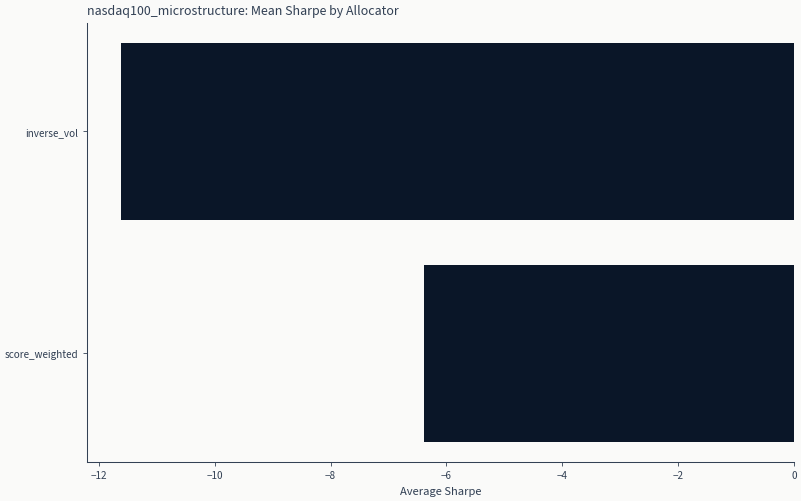

In [11]:
import matplotlib.pyplot as plt

from utils.style import show_with_alt

if not alloc_comparison.is_empty():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(alloc_comparison["allocator"].to_list(), alloc_comparison["avg_sharpe"].to_list())
    ax.set_xlabel("Average Sharpe")
    ax.set_title(f"{CASE_STUDY_ID}: Mean Sharpe by Allocator")
    # No `tight_layout()`: `utils/style` and `matplotlibrc` both set
    # `figure.constrained_layout.use`, so calling it warns and fights the layout engine that
    # is already running. `show_with_alt` rather than `fig.show()`, which on a non-interactive
    # backend warns that the canvas cannot be shown and publishes a figure with no alt text.
    # Both are what the six notebooks of this case study already at `done` do.
    #
    # The alt text names the structure and not the ranking. Which allocator leads is a
    # registry result that a rebuild can reverse, and an alt string is prose that no rebuild
    # revisits - so a described ordering here would go stale silently, on the one surface a
    # reader who cannot see the chart depends on.
    show_with_alt(
        fig,
        "Horizontal bar chart of mean Sharpe by allocator. One bar per allocator named on "
        "the vertical axis; bar length is that allocator's average Sharpe across the "
        "configurations it was run on, read on the horizontal axis. Bars left of zero are "
        "allocators whose average is negative.",
    )

### The strongest allocation combinations

The highest-scoring combinations of prediction, position count and allocator.
They pass to the cost notebook as the input surface for the rebalancing-cadence
sweep, which varies how often the same ordering is traded. Nothing is selected
here.

In [12]:
top10 = explorer.best(stage="allocation", top_n=10)
print(top10.select("source", "sharpe", "cagr", "max_drawdown"))

shape: (10, 4)
┌────────────────────────────┬───────────┬───────────┬──────────────┐
│ source                     ┆ sharpe    ┆ cagr      ┆ max_drawdown │
│ ---                        ┆ ---       ┆ ---       ┆ ---          │
│ str                        ┆ f64       ┆ f64       ┆ f64          │
╞════════════════════════════╪═══════════╪═══════════╪══════════════╡
│ gbm/default_mse            ┆ -2.376497 ┆ -0.773808 ┆ -0.771615    │
│ ensemble/gbm_mean_leaves31 ┆ -2.85879  ┆ -0.707268 ┆ -0.713649    │
│ ensemble/gbm_mean_leaves31 ┆ -3.378137 ┆ -0.714562 ┆ -0.718315    │
│ gbm/default_mse            ┆ -3.766977 ┆ -0.827426 ┆ -0.825401    │
│ gbm/default_mse            ┆ -4.041233 ┆ -0.646184 ┆ -0.641625    │
│ ensemble/gbm_mean_leaves31 ┆ -4.065079 ┆ -0.701836 ┆ -0.697953    │
│ gbm/leaves_15_huber        ┆ -4.081632 ┆ -0.744413 ┆ -0.745706    │
│ gbm/leaves_15_mae          ┆ -4.09838  ┆ -0.731928 ┆ -0.722508    │
│ gbm/leaves_31_huber        ┆ -4.133518 ┆ -0.685828 ┆ -0.693595    │
│ gbm

## Key Takeaways

1. **An allocator decides sizes, not turnover.** Every configuration in this
   grid rebalances at the same times, so the differences between them are
   differences in how capital is spread across positions. When the cost of
   turning positions over dominates, redistributing weight across them cannot
   recover it, and the allocator comparison is measuring a second-order effect.

2. **Covariance-based allocation needs an estimate the data may not support.**
   Mean-variance and hierarchical risk parity require a correlation matrix
   between assets. Estimated from short-horizon returns, that matrix is noisy,
   and a weighting scheme built on a noisy correlation is not more principled
   than an equal weighting - it is differently wrong and more expensive.

3. **Position count is a concentration decision.** Holding more names spreads
   the same capital more thinly, which reduces the contribution of any single
   position, correct or not, and increases the number of positions paying
   costs. It moves the outcome without addressing what drives it.

4. **Allocation sits downstream of the cost problem.** Position sizing can only
   distribute whatever the signal and the trading rule leave behind. The lever
   that acts on the cost itself is how often the strategy trades, which is what
   the cost notebook sweeps.

**Known limitations**: Every result here is computed on the whole universe at
one rebalancing frequency, so it describes allocation under those conditions
only. Covariance-based allocators are excluded by default and their inclusion
is a configuration change, not a change to the comparison being made.